# Prerequisites · M1 — Linear Algebra for Deep Learning

> **Goal:** the linear algebra that the rest of this repo *actually uses* — vectors, the matmul, transpose, eigenvalues, and the **SVD** — built and visualized from scratch, with each idea tied to the exact notebook where it shows up. Not a general course; the specific machinery under autograd, attention, LoRA, and diffusion.

**Why start here.** Deep learning *is* applied linear algebra. Data is vectors; a layer is a matrix multiply; a network is a composition of linear maps with nonlinearities between them; training is calculus *on* those linear maps. If matmul, transpose, and SVD feel fuzzy, everything above wobbles. This notebook makes them concrete — and every section ends with **"↳ used in Notebook X"** so you see *why* it matters, not just *what* it is.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)
print("numpy", np.__version__)


numpy 1.26.4


## 1. Vectors: dot products, norms, and similarity

A **vector** is a list of numbers — a point in space, or a direction. In DL, *everything* becomes a vector: a word embedding, an image flattened, a layer's activations. Two operations dominate:

- **Norm** $\|x\| = \sqrt{\sum_i x_i^2}$ — the vector's length (used in gradient clipping, weight decay, normalization).
- **Dot product** $x\cdot y = \sum_i x_i y_i = \|x\|\|y\|\cos\theta$ — measures **alignment**. It's the single most important scalar in DL: attention scores are dot products (query·key), a neuron's pre-activation is a dot product (weights·inputs), and **cosine similarity** $\dfrac{x\cdot y}{\|x\|\|y\|}$ measures how similar two embeddings are.


|a| = 2.236  (numpy: 2.236)
cos(a,b) = 0.707  (a and b partly aligned)
cos(a,c) = 1.000  (a and c parallel -> similarity 1.0)


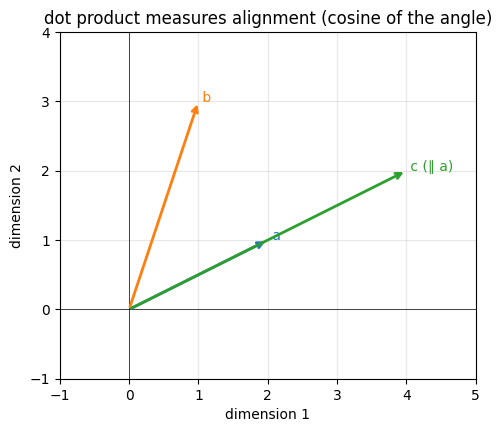

In [2]:
def norm(x): return np.sqrt(np.sum(x**2))
def dot(x, y): return np.sum(x*y)
def cosine(x, y): return dot(x,y)/(norm(x)*norm(y))

a = np.array([2.0, 1.0]); b = np.array([1.0, 3.0]); c = np.array([4.0, 2.0])  # c is parallel to a
print(f"|a| = {norm(a):.3f}  (numpy: {np.linalg.norm(a):.3f})")
print(f"cos(a,b) = {cosine(a,b):.3f}  (a and b partly aligned)")
print(f"cos(a,c) = {cosine(a,c):.3f}  (a and c parallel -> similarity 1.0)")

fig, ax = plt.subplots(figsize=(5,5))
for v,l,col in [(a,"a","tab:blue"),(b,"b","tab:orange"),(c,"c (∥ a)","tab:green")]:
    ax.annotate("", xy=v, xytext=(0,0), arrowprops=dict(arrowstyle="->", color=col, lw=2))
    ax.text(v[0], v[1], f" {l}", color=col)
ax.set_xlim(-1,5); ax.set_ylim(-1,4); ax.axhline(0,color="k",lw=0.5); ax.axvline(0,color="k",lw=0.5)
ax.set_title("dot product measures alignment (cosine of the angle)")
ax.set_xlabel("dimension 1"); ax.set_ylabel("dimension 2"); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()


**↳ Used in:** attention scores $QK^{\mathsf T}$ (NB10) are dot products; a neuron's $w\cdot x + b$ (NB01) is a dot product; cosine similarity is how CLIP matches images and text (NB40) and how RAG retrieves documents (NB41).


## 2. The matrix multiply — the core operation of deep learning

A **matrix** is a grid of numbers, and **matrix multiplication** $C = AB$ is *the* operation: a neural network layer is $y = Wx + b$, and 90%+ of a model's compute is matmuls. Two ways to read $AB$:
1. **Row × column of dot products:** $C_{ij} = \sum_k A_{ik}B_{kj}$ — entry $(i,j)$ is the dot product of row $i$ of $A$ with column $j$ of $B$.
2. **A linear transformation:** $A$ *maps* each column-vector of $B$ to a new vector. This is the geometric view — a matrix moves points around space (rotate, scale, shear).

Shapes must match: $(m\times k)(k\times n) = (m\times n)$ — the inner dimensions cancel. Getting shapes right is half of debugging deep learning.


our matmul matches numpy: True


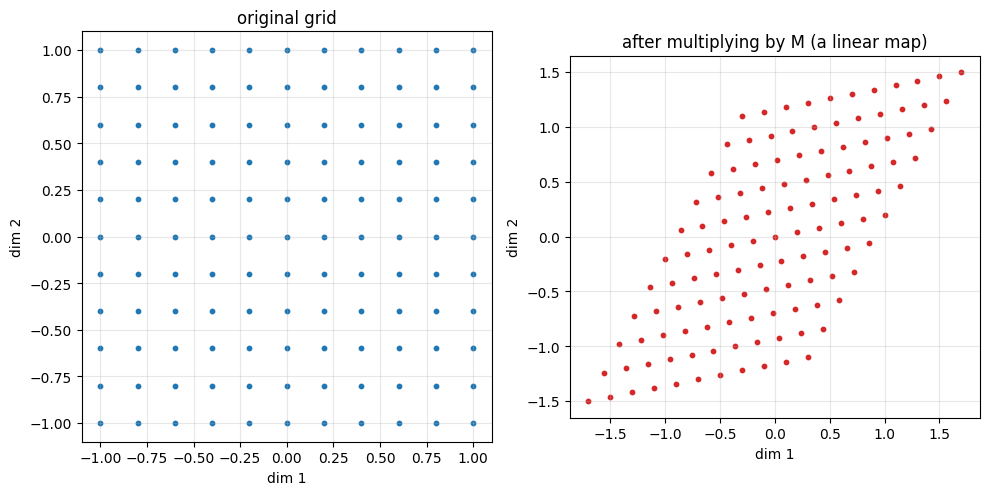

In [3]:
def matmul(A, B):                        # from scratch, the dot-product view
    m, k = A.shape; k2, n = B.shape
    assert k == k2, f"shape mismatch: {A.shape} @ {B.shape}"
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            C[i,j] = np.sum(A[i,:] * B[:,j])   # row i of A dotted with column j of B
    return C

A = np.random.randn(3,4); B = np.random.randn(4,2)
print("our matmul matches numpy:", np.allclose(matmul(A,B), A @ B))

# the geometric view: a 2x2 matrix transforms a grid of points
M = np.array([[1.0, 0.7],[0.2, 1.3]])       # a shear + scale
grid = np.array([[x,y] for x in np.linspace(-1,1,11) for y in np.linspace(-1,1,11)]).T  # (2, N)
transformed = M @ grid
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].scatter(grid[0], grid[1], s=10, c="tab:blue"); ax[0].set_title("original grid")
ax[1].scatter(transformed[0], transformed[1], s=10, c="tab:red"); ax[1].set_title("after multiplying by M (a linear map)")
for a in ax: a.set_aspect("equal"); a.grid(alpha=0.3); a.set_xlabel("dim 1"); a.set_ylabel("dim 2")
plt.tight_layout(); plt.show()


**↳ Used in:** literally everywhere — `x @ W` is every Linear layer (NB02, NB06), attention is three matmuls (NB10), and the whole point of Tier 3 (FlashAttention, parallelism) is doing matmuls efficiently at scale.


## 3. Transpose — and why gradients transpose

The **transpose** $A^{\mathsf T}$ flips rows and columns: $(A^{\mathsf T})_{ij} = A_{ji}$. It looks trivial but it's *everywhere* in backprop. The key fact you derived in NB02: if the forward pass is $Y = XW$, the backward pass sends gradients through the **transposes**:
$$\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y}\,W^{\mathsf T}, \qquad \frac{\partial L}{\partial W} = X^{\mathsf T}\,\frac{\partial L}{\partial Y}.$$
Why? Because the transpose is the **adjoint** — it's the unique operation that "reverses" a linear map for the purpose of moving gradients backward through it. Every backward pass in autograd is, at heart, multiplying by a transpose.


In [4]:
X = np.random.randn(5, 3); W = np.random.randn(3, 4)
Y = X @ W
dY = np.random.randn(*Y.shape)              # pretend gradient flowing back
dX = dY @ W.T                               # gradient to input: dY W^T
dW = X.T @ dY                               # gradient to weights: X^T dY
print(f"forward  X{X.shape} @ W{W.shape} = Y{Y.shape}")
print(f"backward dX = dY @ W.T -> {dX.shape}  (matches X)  ✓ {dX.shape==X.shape}")
print(f"backward dW = X.T @ dY -> {dW.shape}  (matches W)  ✓ {dW.shape==W.shape}")
print("\nMnemonic: the gradient of a thing always has that thing's shape — the transposes make the shapes line up.")


forward  X(5, 3) @ W(3, 4) = Y(5, 4)
backward dX = dY @ W.T -> (5, 3)  (matches X)  ✓ True
backward dW = X.T @ dY -> (3, 4)  (matches W)  ✓ True

Mnemonic: the gradient of a thing always has that thing's shape — the transposes make the shapes line up.


**↳ Used in:** every `_backward` in the autograd engine (NB01–02), the hand-derived layer gradients (NB03), and the matmul backward is *the* reason attention has a clean backward pass.


## 4. Eigenvalues & eigenvectors — the directions a matrix leaves alone

For a square matrix $A$, an **eigenvector** $v$ is a special direction that $A$ only *stretches* (doesn't rotate): $Av = \lambda v$, where the scalar $\lambda$ is the **eigenvalue** (the stretch factor). Eigenvalues tell you what a matrix *does* to repeated application: the largest $|\lambda|$ (the **spectral radius**) governs whether repeatedly applying $A$ blows up ($|\lambda|>1$) or dies ($|\lambda|<1$).

We can find the top eigenvector from scratch with **power iteration**: repeatedly multiply a random vector by $A$ and normalize — it converges to the dominant eigenvector (because that direction gets amplified most).


power iteration top eigenvalue: 3.0000
numpy eigenvalues:              [3.0, 1.0]


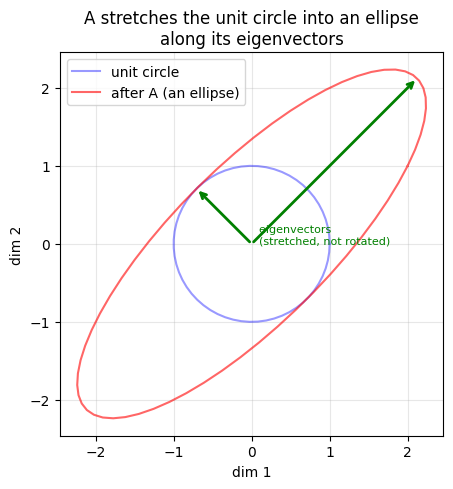

In [5]:
def power_iteration(A, iters=200):
    v = np.random.randn(A.shape[0]); v /= np.linalg.norm(v)
    for _ in range(iters):
        v = A @ v; v /= np.linalg.norm(v)          # multiply and renormalize
    lam = (v @ A @ v) / (v @ v)                     # Rayleigh quotient = eigenvalue
    return lam, v

A = np.array([[2.0, 1.0],[1.0, 2.0]])              # symmetric -> real eigenvalues
lam, v = power_iteration(A)
eigvals, eigvecs = np.linalg.eig(A)
print(f"power iteration top eigenvalue: {lam:.4f}")
print(f"numpy eigenvalues:              {sorted(eigvals, reverse=True)}")

fig, ax = plt.subplots(figsize=(5,5))
circle = np.array([[np.cos(t), np.sin(t)] for t in np.linspace(0,2*np.pi,60)]).T
ax.plot(circle[0], circle[1], "b-", alpha=0.4, label="unit circle")
Ac = A @ circle
ax.plot(Ac[0], Ac[1], "r-", alpha=0.6, label="after A (an ellipse)")
for i in range(2):
    e = eigvecs[:,i]*eigvals[i]
    ax.annotate("", xy=e, xytext=(0,0), arrowprops=dict(arrowstyle="->",color="green",lw=2))
ax.text(0,0,"  eigenvectors\n  (stretched, not rotated)", color="green", fontsize=8)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(); ax.set_title("A stretches the unit circle into an ellipse\nalong its eigenvectors")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2"); plt.tight_layout(); plt.show()


**↳ Used in:** the RNN vanishing/exploding gradient is governed by the spectral radius of $W_{hh}$ (NB08); an optimizer's convergence speed depends on the eigenvalue spread (condition number) of the loss curvature (NB04, NB05); and PCA is eigen-decomposition of the covariance matrix.


## 5. The SVD — the most useful decomposition in ML

The **Singular Value Decomposition** factors *any* matrix (square or not) as
$$A = U\Sigma V^{\mathsf T},$$
where $U, V$ are orthogonal (rotations) and $\Sigma$ is diagonal with non-negative **singular values** $\sigma_1 \ge \sigma_2 \ge \dots \ge 0$ (stretch factors). Geometrically: *every* linear map is a **rotation → axis-aligned scaling → rotation**. The singular values rank the "importance" of each direction.

**The killer application: low-rank approximation.** Keeping only the top $k$ singular values gives the *best possible rank-$k$ approximation* of $A$ (Eckart–Young theorem). This is the mathematical core of **image compression, PCA, and LoRA**. Let's demonstrate it by compressing an image.


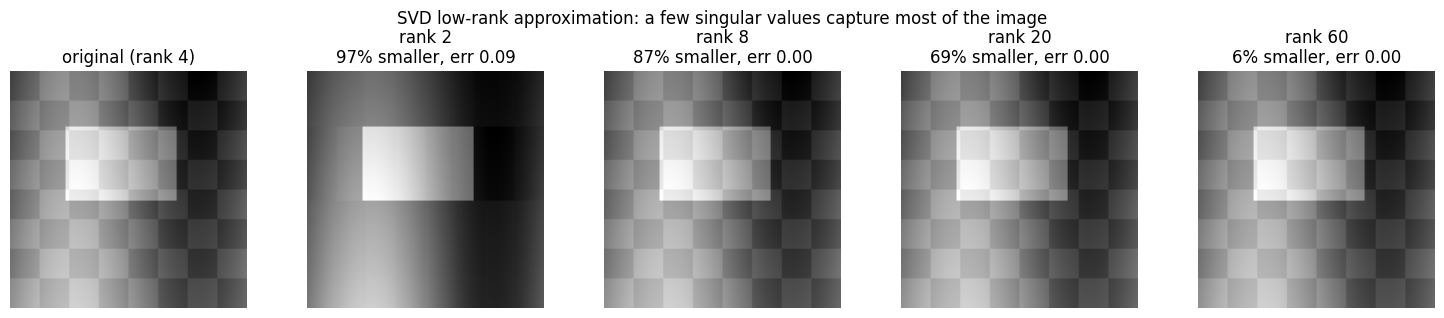

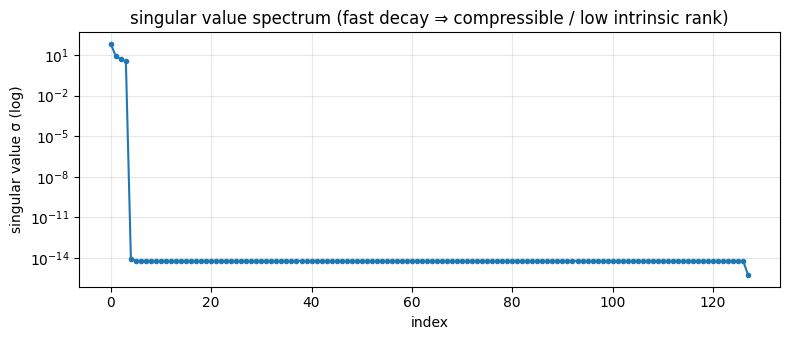

In [6]:
# build a structured grayscale image (gradient + shapes + texture) so its SVD spectrum is interesting
n = 128
yy, xx = np.mgrid[0:n, 0:n] / n
img = 0.5*np.sin(6*xx) + 0.5*yy                                  # smooth low-rank part
img[30:70, 30:90] += 0.6                                          # a bright rectangle (sharp)
img += 0.15*(((xx*8).astype(int)+(yy*8).astype(int)) % 2)        # checker texture
img = (img - img.min())/(img.max()-img.min())

U, S, Vt = np.linalg.svd(img, full_matrices=False)               # THE SVD
def rank_k(k): return (U[:,:k] * S[:k]) @ Vt[:k]                  # keep top-k singular values

fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
ax[0].imshow(img, cmap="gray"); ax[0].set_title(f"original (rank {np.linalg.matrix_rank(img)})"); ax[0].axis("off")
for a, k in zip(ax[1:], [2, 8, 20, 60]):
    recon = rank_k(k); err = np.linalg.norm(img-recon)/np.linalg.norm(img)
    a.imshow(recon, cmap="gray"); a.set_title(f"rank {k}\n{100*(1-k*(2*n+1)/n**2):.0f}% smaller, err {err:.2f}"); a.axis("off")
fig.suptitle("SVD low-rank approximation: a few singular values capture most of the image")
plt.tight_layout(); plt.show()

# the singular value spectrum
fig, ax = plt.subplots(figsize=(8,3.5))
ax.semilogy(S, "-o", ms=3); ax.set_title("singular value spectrum (fast decay ⇒ compressible / low intrinsic rank)")
ax.set_xlabel("index"); ax.set_ylabel("singular value σ (log)"); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** A rank-20 reconstruction (out of 128) is already visually close to the original — the singular values **decay fast**, so most of the image lives in a few directions. That "fast-decaying spectrum ⇒ low intrinsic rank" is *exactly* the premise of **LoRA** (NB20): fine-tuning updates are low-rank, so a rank-$r$ $BA$ captures them; and of **double descent's** peak (NB28), where the readout norm blows up. It's also **PCA** (keep the top singular directions of the data).

**↳ Used in:** LoRA low-rank adapters (NB20), the double-descent analysis (NB28), PCA/dimensionality reduction, and the intuition that neural representations live on low-dimensional manifolds.


## 6. Determinant & Jacobian — how much a map scales volume

The **determinant** $\det(A)$ of a square matrix is the factor by which it scales **volume** (area in 2-D): $\det = 2$ means the map doubles areas; $\det = 0$ means it collapses space to a lower dimension (non-invertible). For a nonlinear map, the local volume-scaling is the determinant of its **Jacobian** matrix (the matrix of all partial derivatives — you'll build the Jacobian properly in M2).

This is the beating heart of **normalizing flows** (NB26): the change-of-variables formula $\log p(x) = \log p_z(f(x)) + \log|\det J_f|$ uses $\log|\det J|$ to account for how the invertible map $f$ stretches probability density.


det(M) = 2.500
area of mapped square = 2.500  (should equal |det M| = 2.500)


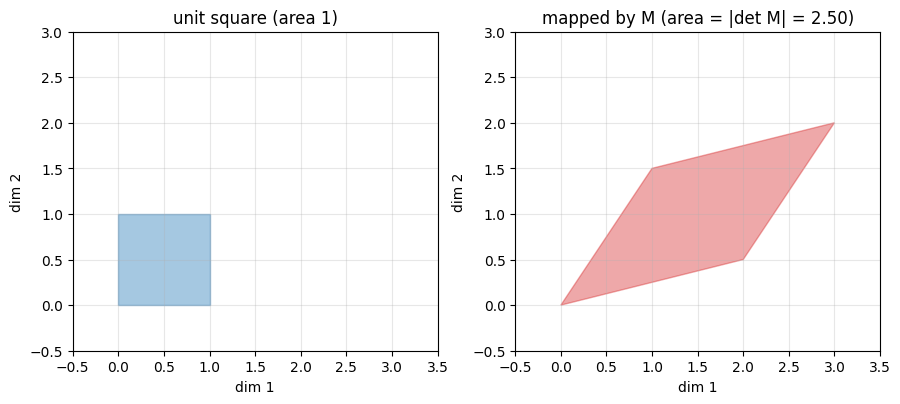

In [7]:
# determinant as area scaling: map the unit square by M, measure the area
M = np.array([[2.0, 1.0],[0.5, 1.5]])
unit_square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
mapped = M @ unit_square
det = np.linalg.det(M)
# area of a polygon via the shoelace formula (from scratch)
def poly_area(p):
    x, y = p[0], p[1]; return 0.5*abs(np.sum(x[:-1]*y[1:] - x[1:]*y[:-1]))
print(f"det(M) = {det:.3f}")
print(f"area of mapped square = {poly_area(mapped):.3f}  (should equal |det M| = {abs(det):.3f})")

fig, ax = plt.subplots(1,2,figsize=(9,4.5))
ax[0].fill(unit_square[0], unit_square[1], alpha=0.4, color="tab:blue"); ax[0].set_title("unit square (area 1)")
ax[1].fill(mapped[0], mapped[1], alpha=0.4, color="tab:red"); ax[1].set_title(f"mapped by M (area = |det M| = {abs(det):.2f})")
for a in ax: a.set_aspect("equal"); a.grid(alpha=0.3); a.set_xlim(-0.5,3.5); a.set_ylim(-0.5,3); a.set_xlabel("dim 1"); a.set_ylabel("dim 2")
plt.tight_layout(); plt.show()


**↳ Used in:** normalizing flows' change-of-variables (NB26) — the whole reason coupling layers use a triangular Jacobian is that its determinant is a cheap product of the diagonal.


## 7. Putting it together — a neural network is composed linear algebra

Every forward pass you've built is this recipe: **linear map → nonlinearity → linear map → …**. The linear maps are matmuls (Sections 2–3); their gradients flow back through transposes (Section 3); their conditioning affects optimization (Section 4); their low-rank structure enables LoRA (Section 5); and invertible ones with tractable determinants give flows (Section 6). Here's a 2-layer net's forward pass written in raw linear algebra:


In [8]:
def relu(x): return np.maximum(0, x)
x = np.random.randn(1, 8)                          # a single input vector (as a row)
W1 = np.random.randn(8, 16); b1 = np.zeros(16)
W2 = np.random.randn(16, 4); b2 = np.zeros(4)
h  = relu(x @ W1 + b1)                              # linear map -> nonlinearity
y  = h @ W2 + b2                                    # linear map -> output
print(f"input {x.shape} → hidden {h.shape} → output {y.shape}")
print("that's the entire forward pass of a neural net — just matmuls, a bias add, and a nonlinearity.")


input (1, 8) → hidden (1, 16) → output (1, 4)
that's the entire forward pass of a neural net — just matmuls, a bias add, and a nonlinearity.


**The big picture.** You now have the vocabulary the whole repo speaks: a **layer** is a matmul, **backprop** is transposes, **stability** is eigenvalues/conditioning, **compression & LoRA** are the SVD, and **flows** are determinants. With this, Tier 0's autograd and everything above reads as applied linear algebra.

## What you learned
- **Vectors**: norms, dot products, cosine similarity (the alignment measure behind attention & retrieval).
- **Matmul**: the core op, as dot products *and* as a linear transformation of space.
- **Transpose**: the adjoint — why every backward pass multiplies by a transpose.
- **Eigenvalues**: the directions a matrix preserves; spectral radius governs stability (RNNs, optimization).
- **SVD**: the best low-rank approximation — image compression, PCA, LoRA, double descent.
- **Determinant/Jacobian**: volume scaling — the engine of normalizing flows.

## Exercises
1. **Matmul associativity.** Verify $(AB)C = A(BC)$ but the FLOP cost differs; when does chaining order matter (hint: attention $QK^{\mathsf T}V$)?
2. **Orthogonal matrices.** Show a rotation matrix has $Q^{\mathsf T}Q=I$ and preserves norms; why is orthogonal init nice for deep nets?
3. **PCA from SVD.** Implement PCA by taking the SVD of mean-centered data; project MNIST to 2-D and plot.
4. **Rank of a product.** Show $\text{rank}(AB) \le \min(\text{rank }A,\text{rank }B)$ — the constraint that makes LoRA's $BA$ low-rank.
5. **Condition number.** Compute $\sigma_{\max}/\sigma_{\min}$ for a few matrices; relate high condition number to slow optimization (NB04).
6. **Jacobian determinant.** For $f(x,y)=(x+y^2,\,2y)$, compute the Jacobian and its determinant by hand and numerically.

## 📚 References & further reading
- **Introduction to Linear Algebra** — Gilbert Strang. The canonical text (and his MIT OCW lectures).
- **Deep Learning** — Goodfellow, Bengio & Courville (2016), Chapter 2 ("Linear Algebra"). The DL-focused summary.
- **The Matrix Cookbook** — Petersen & Pedersen. A reference for matrix identities and derivatives.
- **Essence of Linear Algebra** — 3Blue1Brown (video series). The best geometric intuition for transformations, eigenvectors, and determinants.

---
**Next:** *Prerequisites · M2 — Calculus & vector calculus*: derivatives, partial derivatives, the gradient, the Jacobian, and the multivariate chain rule — the calculus that makes backpropagation (NB01) work.
